In [1]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import joblib
#Loading data
df=pd.read_csv(r'D:\Python\ML\Projects\Linear\Auto-mpg\auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


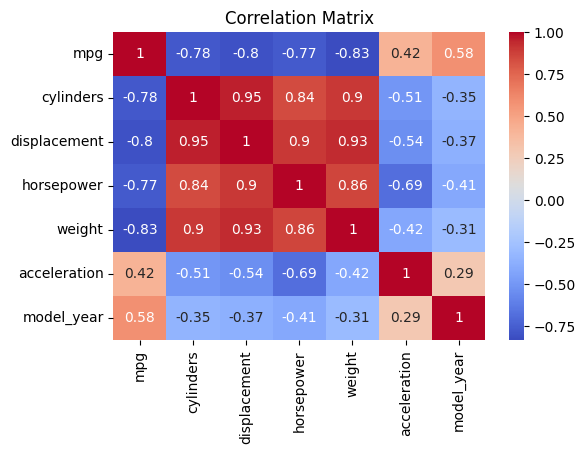

In [ ]:
#correlation matrix to see the relationship between the columns and to identify which features are more correlated with the target variable 'mpg'.
corr_matrix=df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [4]:
#Data preprocessing
df=df.drop(['car name','origin'],axis=1)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70


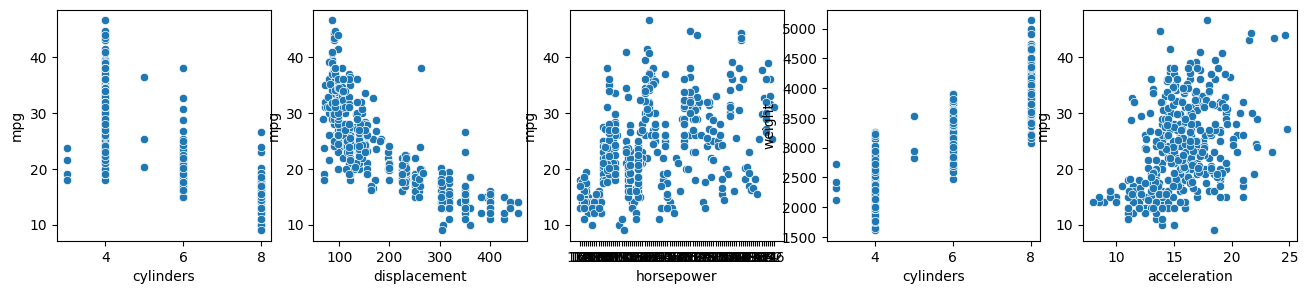

In [5]:
#Data visualization to understand the relationship between features and target variable
plt.figure(figsize=(16,3))
sns.scatterplot(x='cylinders',y='mpg',data=df,ax=plt.subplot(1,5,1))
sns.scatterplot(x='displacement',y='mpg',data=df,ax=plt.subplot(1,5,2))
sns.scatterplot(x='horsepower',y='mpg',data=df,ax=plt.subplot(1,5,3))
sns.scatterplot(x='cylinders',y='weight',data=df,ax=plt.subplot(1,5,4))
sns.scatterplot(x='acceleration',y='mpg',data=df,ax=plt.subplot(1,5,5))
plt.show()

In [ ]:
#Converting horsepower to numeric
df['horsepower']=pd.to_numeric(df['horsepower'],errors='coerce')

In [7]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
dtype: object

In [8]:
#Renaming columns for better readability
df.columns=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year']

In [9]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year'],
      dtype='object')

In [10]:
#filling missing values in horsepower with median
df['horsepower'].fillna(df['horsepower'].median(),inplace=True)

C:\Users\haris\AppData\Local\Temp\ipykernel_20080\603752618.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(),inplace=True)


In [11]:
#Splitting data into features and target variable
X=df.drop(['mpg'],axis=1)
y=df['mpg']

In [12]:
#Splitting data into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
#Feature scaling used to standardize the features by removing the mean and scaling to unit variance
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [14]:
#Training the linear regression model
model1=LinearRegression()
model1.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred=model1.predict(X_test_scaled)

In [16]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [17]:
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2-SCORE: {r2:.2f}")

MAE: 2.47
MSE: 9.44
RMSE: 3.07
R2-SCORE: 0.82


In [18]:
coef_df=pd.DataFrame({'Feature':X.columns,'coefficient':model1.coef_})
print(coef_df)

        Feature  coefficient
0     cylinders     0.116161
1  displacement     0.164881
2    horsepower     0.107313
3        weight    -5.911743
4  acceleration     0.222408
5    model_year     2.882916


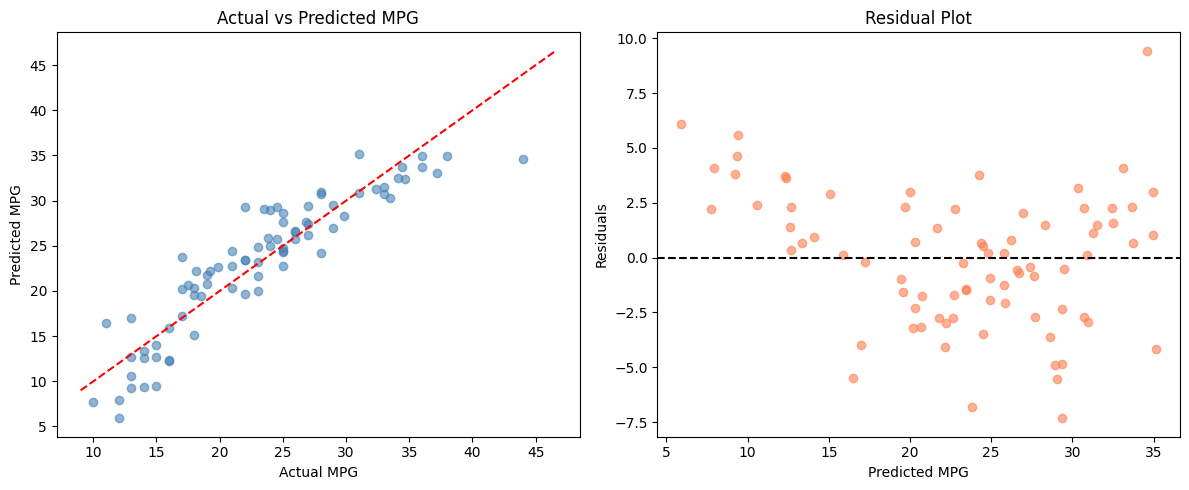

In [30]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color='coral', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()